<a href="https://colab.research.google.com/github/hitomitsu50/Sports_data_portfolio_MLB_Statcast/blob/main/2025%E5%B9%B4Statcast%E5%B1%B1%E6%9C%AC%E6%8A%95%E6%89%8B_%E6%8A%95%E7%90%83%E5%89%B2%E5%90%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pybaseball japanize_matplotlib
!sudo apt-get -y update
!sudo apt-get -y install fonts-ipaexfont

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-ipaexfont is already the newest version (00401-3ubuntu1).
0 upgraded, 0 newly installed,

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib
import glob
import time
from pybaseball import statcast

In [ ]:
#データの読み込みと結合
#パターンに一致するＣＳＶファイルを取得
csv_files_pattern=("sample_data/statcast_*.csv")
csv_files=glob.glob(csv_files_pattern)

In [ ]:
#データの読み込みと格納
dfs=[]
for file in csv_files:
  try:
    df_month=pd.read_csv(file)
    dfs.append(df_month)
    print(f"{file}を読み込みました。")
  except Exception as e:
    print(f"{file}を読み込み中エラーが発生:{e}")

sample_data/statcast_2025-03-18-2025-03-31.csvを読み込みました。
sample_data/statcast_2025-07-01-2025-07-31.csvを読み込みました。
sample_data/statcast_2025-05-01-2025-05-31.csvを読み込みました。
sample_data/statcast_2025-09-01-2025-09-28.csvを読み込みました。
sample_data/statcast_2025-06-01-2025-06-30.csvを読み込みました。
sample_data/statcast_2025-04-01-2025-04-30.csvを読み込みました。
sample_data/statcast_2025-08-01-2025-08-31.csvを読み込みました。


In [ ]:
#データの結合
if dfs:
  df_combined=pd.concat(dfs,ignore_index=True)
  df=df_combined
  print("全てのファイルを結合")
  display(df.head())
  print(f"結合後の行数:{len(df)}")
else:
  print("読み込めるファイルがありません。")

全てのファイルを結合


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,SI,2025-03-31,96.6,0.22,7.01,"Bautista, Félix",608324,642585,field_out,hit_into_play,...,2.0,0.86,0.33,0.33,69.1,NaN,NaN,NaN,NaN,NaN
1,SL,2025-03-31,86.8,-0.50,6.78,"Bautista, Félix",608324,642585,NaN,ball,...,2.0,3.02,-0.52,-0.52,57.4,NaN,NaN,NaN,NaN,NaN
2,SI,2025-03-31,97.8,0.18,7.03,"Bautista, Félix",646240,642585,walk,ball,...,2.0,0.77,0.38,-0.38,68.6,NaN,NaN,NaN,NaN,NaN
3,SI,2025-03-31,97.8,0.18,6.95,"Bautista, Félix",646240,642585,NaN,foul,...,2.0,0.71,0.38,-0.38,73.1,2.326145,17.900737,28.548852,43.512056,18.085586
4,SI,2025-03-31,97.7,0.05,7.02,"Bautista, Félix",646240,642585,NaN,called_strike,...,2.0,0.59,0.39,-0.39,71.4,NaN,NaN,NaN,NaN,NaN


結合後の行数:742080


In [ ]:
# --- 1. データ抽出と基本集計 ---
target_name_display="Yoshinobu Yamamoto"
df_target=df[df["player_name"].str.contains("Yamamoto, Yoshinobu")].copy()

#球種ごとのカウント、平均球速、平均回転数
pitch_stats=df_target.groupby("pitch_type").agg({
    "pitch_type":"count",
    "release_speed":"mean",
    "release_spin_rate":"mean" # Changed 'release_spin' to 'release_spin_rate'
}).rename(columns={"pitch_type":"count"}).sort_values("count",ascending=False)

In [ ]:
# --- 2. Whiff%とPutAway%の計算 ---
# Whiff% = 空振り/スイング
swings=df_target[df_target["description"].isin(["swinging_strike","foul","foul_tip",
                                                "hit_into_play","swinging_strike_blocjed"])]
whiffs=df_target[df_target["description"].isin(["swinging_strike","swinging_strike_blocked"])]

#PutAway% = 2ストライクから三振/2ストライク投球数
two_strikes=df_target[df_target["strikes"]==2]
strikeouts=two_strikes[df_target["events"].isin(["strikeout","strikeout_double_play"])]

#球種ごとの計算値を結合
pitch_stats["whiff_pct"]=(whiffs.groupby("pitch_type").size()/swings.groupby("pitch_type").size()*100)
pitch_stats["putaway_pct"]=(strikeouts.groupby("pitch_type").size()/two_strikes.groupby("pitch_type").size()*100)
pitch_stats["usage_pct"]=(pitch_stats["count"]/pitch_stats["count"].sum()*100)

/tmp/ipython-input-225734895.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  strikeouts=two_strikes[df_target["events"].isin(["strikeout","strikeout_double_play"])]


/tmp/ipython-input-3428113098.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pitch_stats.index, y=pitch_stats["usage_pct"],ax=ax1,palette="Blues_d",alpha=0.7)


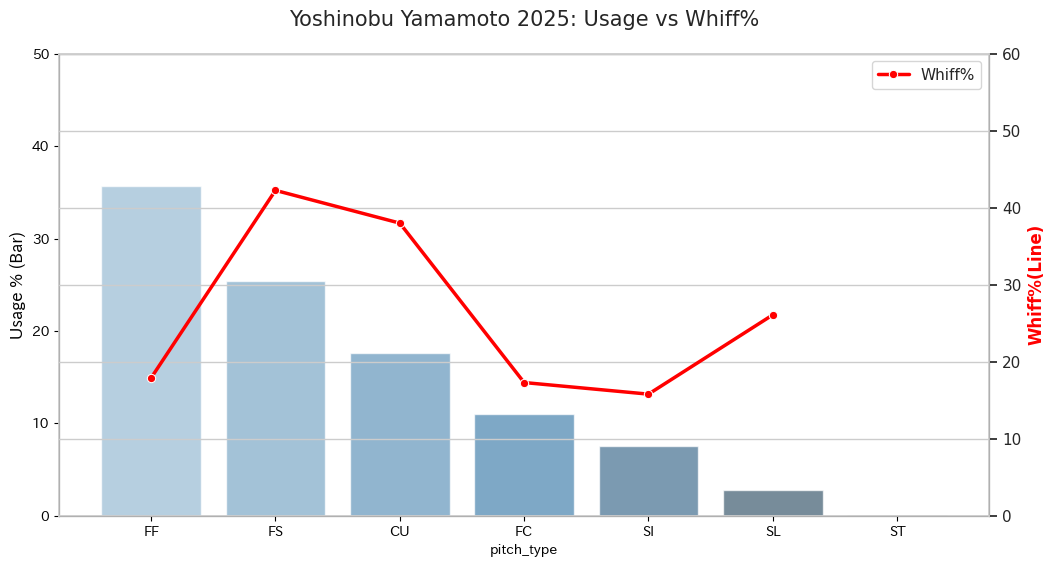

In [ ]:
# --- 3. 可視化(2軸棒グラフ:割合 × Whiff％) ---
fig, ax1=plt.subplots(figsize=(12,6))
sns.set_theme(style="whitegrid")

#左軸 ： 投球割合（棒グラフ）
sns.barplot(x=pitch_stats.index, y=pitch_stats["usage_pct"],ax=ax1,palette="Blues_d",alpha=0.7)
ax1.set_ylabel("Usage % (Bar)",fontsize=12,fontweight="bold")
ax1.set_ylim(0,50)

#右軸 ： Whiff%(折れ線グラフ)
ax2=ax1.twinx()
sns.lineplot(x=pitch_stats.index, y=pitch_stats["whiff_pct"],ax=ax2,color="red",marker="o",linewidth=2.5,label="Whiff%")
ax2.set_ylabel("Whiff%(Line)",color="red",fontsize=12,fontweight="bold")
ax2.set_ylim(0,60)

plt.title(f"{target_name_display} 2025: Usage vs Whiff%",fontsize=15,pad=20)
plt.show()

In [ ]:
# --- 4. テキスト出力（df） ---
jp_names={
    "FF":"フォーシーム",
    "FS":"スプリット",
    "CU":"カーブ",
    "FC":"カットボール",
    "SI":"シンカー",
    "SL":"スライダー",
    "ST":"スイーパー"
}
table_data=[]
for pitch in pitch_stats.index:
  row=pitch_stats.loc[pitch]
  table_data.append({
      "略称": pitch,
      "日本語名": jp_names.get(pitch,pitch),
      "投球数": int(row["count"]),
      "割合": f"{row["usage_pct"]:.1f}%",
      "平均球速": f"{row["release_speed"]:.1f} mph",
      "回転数": f"{int(row["release_spin_rate"])} rpm",
      "Whiff%": f"{row["whiff_pct"]:.1f}%",
      "PutAway%": f"{row["putaway_pct"]:.1f}%"
  })

print(f"### {target_name_display} 2025 Pitch Mix Detail")
display(pd.DataFrame(table_data))
print(f"Total Pitches:{int(pitch_stats["count"].sum())}")

### Yoshinobu Yamamoto 2025 Pitch Mix Detail


,略称,日本語名,投球数,割合,平均球速,回転数,Whiff%,PutAway%
0,FF,フォーシーム,994,35.6%,95.4 mph,2200 rpm,17.9%,22.5%
1,FS,スプリット,708,25.4%,90.9 mph,1426 rpm,42.3%,25.9%
2,CU,カーブ,491,17.6%,76.8 mph,2761 rpm,38.0%,25.2%
3,FC,カットボール,307,11.0%,91.1 mph,2437 rpm,17.3%,19.0%
4,SI,シンカー,209,7.5%,94.8 mph,2234 rpm,15.8%,19.4%
5,SL,スライダー,79,2.8%,86.4 mph,2781 rpm,26.1%,11.9%
6,ST,スイーパー,1,0.0%,84.2 mph,2981 rpm,nan%,nan%


Total Pitches:2789
